In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
sales = pd.read_csv(r'C:\Users\sneha\anaconda assignment\excel\Tractor-Sales.csv')

In [3]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Month-Year              144 non-null    str  
 1   Number of Tractor Sold  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.2 KB


In [4]:
sales.head()

,Month-Year,Number of Tractor Sold
0,Jan-03,141
1,Feb-03,157
2,Mar-03,185
3,Apr-03,199
4,May-03,203


In [5]:
# You should not have missing values
# There should be continuity to the data

In [6]:
sales.columns = ['Month_Year', 'No_Tractors_Sold']

In [7]:
sales.columns

Index(['Month_Year', 'No_Tractors_Sold'], dtype='str')

In [8]:
sales['Month_Year'] = pd.to_datetime(sales.Month_Year, format='%b-%y')

In [9]:
sales.head(1)

,Month_Year,No_Tractors_Sold
0,2003-01-01,141


In [10]:
sales.set_index(sales.Month_Year, inplace=True)

In [11]:
sales['Month_Year'].sort_values(ascending=True)

Month_Year
2003-01-01   2003-01-01
2003-02-01   2003-02-01
2003-03-01   2003-03-01
2003-04-01   2003-04-01
2003-05-01   2003-05-01
                ...    
2014-08-01   2014-08-01
2014-09-01   2014-09-01
2014-10-01   2014-10-01
2014-11-01   2014-11-01
2014-12-01   2014-12-01
Name: Month_Year, Length: 144, dtype: datetime64[us]

In [12]:
sales.head()

,Month_Year,No_Tractors_Sold
Month_Year,,
2003-01-01,2003-01-01,141
2003-02-01,2003-02-01,157
2003-03-01,2003-03-01,185
2003-04-01,2003-04-01,199
2003-05-01,2003-05-01,203


In [13]:
sales['year'] = sales.Month_Year.dt.year
sales['month'] = sales.Month_Year.dt.month

In [14]:
sales

,Month_Year,No_Tractors_Sold,year,month
Month_Year,,,,
2003-01-01,2003-01-01,141,2003,1
2003-02-01,2003-02-01,157,2003,2
2003-03-01,2003-03-01,185,2003,3
2003-04-01,2003-04-01,199,2003,4
2003-05-01,2003-05-01,203,2003,5
...,...,...,...,...
2014-08-01,2014-08-01,848,2014,8
2014-09-01,2014-09-01,640,2014,9
2014-10-01,2014-10-01,581,2014,10


In [15]:
# Fundamental - We need to plot the graphical representation of data
# Understanding what is the pattern in the data
# Continuity in my data

In [16]:
# Line Plot


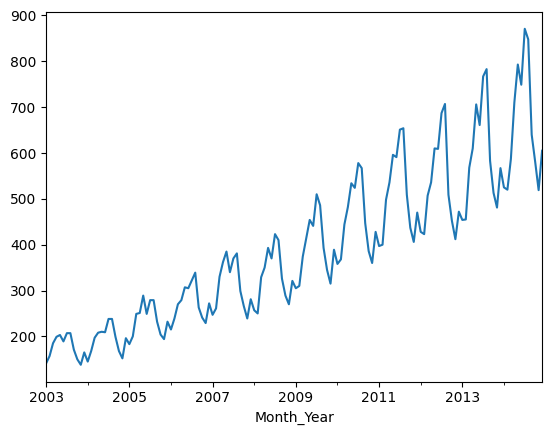

In [17]:
sales.No_Tractors_Sold.plot()
plt.show()

In [18]:
pd.pivot_table(data = sales, index = 'year', columns = 'month', values = 'No_Tractors_Sold')

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2003,141.0,157.0,185.0,199.0,203.0,189.0,207.0,207.0,171.0,150.0,138.0,165.0
2004,145.0,168.0,197.0,208.0,210.0,209.0,238.0,238.0,199.0,168.0,152.0,196.0
2005,183.0,200.0,249.0,251.0,289.0,249.0,279.0,279.0,232.0,204.0,194.0,232.0
2006,215.0,239.0,270.0,279.0,307.0,305.0,322.0,339.0,263.0,241.0,229.0,272.0
2007,247.0,261.0,330.0,362.0,385.0,340.0,370.0,381.0,299.0,266.0,239.0,281.0
2008,257.0,250.0,329.0,350.0,393.0,370.0,423.0,410.0,326.0,289.0,270.0,321.0
2009,305.0,310.0,374.0,414.0,454.0,441.0,510.0,486.0,393.0,345.0,315.0,389.0
2010,358.0,368.0,444.0,482.0,534.0,524.0,578.0,567.0,447.0,386.0,360.0,428.0
2011,397.0,400.0,498.0,536.0,596.0,591.0,651.0,654.0,509.0,437.0,406.0,470.0


In [19]:
#Long to wide data
pd.pivot_table(data = sales, index = 'year', columns = 'month', values = 'No_Tractors_Sold').plot(legend=False)

<Axes: xlabel='year'>

In [20]:
pd.pivot_table(data = sales, index = 'month', columns = 'year', values = 'No_Tractors_Sold').plot(legend=False)

<Axes: xlabel='month'>

In [21]:
sales.No_Tractors_Sold.sort_values(ascending=True)

Month_Year
2003-11-01    138
2003-01-01    141
2004-01-01    145
2003-10-01    150
2004-11-01    152
             ... 
2013-07-01    767
2013-08-01    783
2014-05-01    793
2014-08-01    848
2014-07-01    871
Name: No_Tractors_Sold, Length: 144, dtype: int64

In [22]:
sales.No_Tractors_Sold.sort_values(ascending=False)

Month_Year
2014-07-01    871
2014-08-01    848
2014-05-01    793
2013-08-01    783
2013-07-01    767
             ... 
2004-11-01    152
2003-10-01    150
2004-01-01    145
2003-01-01    141
2003-11-01    138
Name: No_Tractors_Sold, Length: 144, dtype: int64

In [23]:
ts = sales.No_Tractors_Sold

In [24]:
ts

Month_Year
2003-01-01    141
2003-02-01    157
2003-03-01    185
2003-04-01    199
2003-05-01    203
             ... 
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Name: No_Tractors_Sold, Length: 144, dtype: int64

In [25]:
#decom = seasonal_decompose(ts, model='multiplicative')
decom = seasonal_decompose(ts, model='additive')

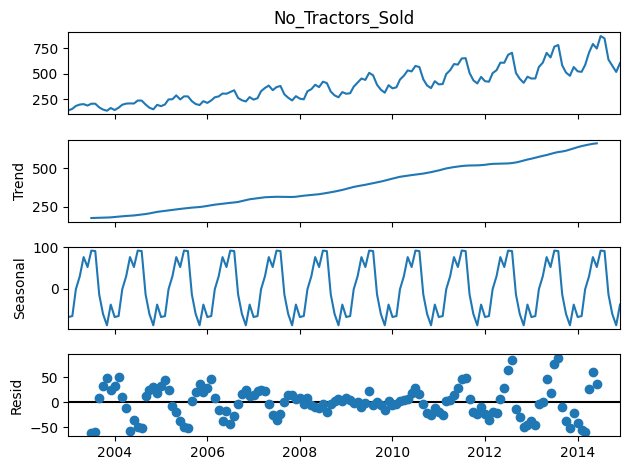

In [26]:
decom.plot()

In [27]:
decom

In [28]:
decom.trend

Month_Year
2003-01-01   NaN
2003-02-01   NaN
2003-03-01   NaN
2003-04-01   NaN
2003-05-01   NaN
              ..
2014-08-01   NaN
2014-09-01   NaN
2014-10-01   NaN
2014-11-01   NaN
2014-12-01   NaN
Name: trend, Length: 144, dtype: float64

In [29]:
pd.concat([decom.observed, decom.trend, decom.seasonal, decom.resid], axis=1).head(12)

,No_Tractors_Sold,trend,seasonal,resid
Month_Year,,,,
2003-01-01,141.0,NaN,-68.763889,NaN
2003-02-01,157.0,NaN,-66.434343,NaN
2003-03-01,185.0,NaN,-1.638889,NaN
2003-04-01,199.0,NaN,29.952020,NaN
2003-05-01,203.0,NaN,75.876263,NaN
2003-06-01,189.0,NaN,51.948232,NaN
2003-07-01,207.0,176.166667,91.584596,-60.751263
2003-08-01,207.0,176.791667,90.482323,-60.273990
2003-09-01,171.0,177.750000,-14.233586,7.483586


In [30]:
207 

207

In [31]:
176.166667	 +  91.584596 -60.751263

207.0

In [32]:
# Objective  T, Se, Irr

In [33]:
ts

Month_Year
2003-01-01    141
2003-02-01    157
2003-03-01    185
2003-04-01    199
2003-05-01    203
             ... 
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Name: No_Tractors_Sold, Length: 144, dtype: int64

In [34]:
ExponentialSmoothing?

Init signature:
ExponentialSmoothing(
    endog,
    trend=None,
    damped_trend=False,
    seasonal=None,
    *,
    seasonal_periods=None,
    initialization_method='estimated',
    initial_level=None,
    initial_trend=None,
    initial_seasonal=None,
    use_boxcox=False,
    bounds=None,
    dates=None,
    freq=None,
    missing='none',
)
Docstring:     
Holt Winter's Exponential Smoothing

Parameters
----------
endog : array_like
    The time series to model.
trend : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of trend component.
damped_trend : bool, optional
    Should the trend component be damped.
seasonal : {"add", "mul", "additive", "multiplicative", None}, optional
    Type of seasonal component.
seasonal_periods : int, optional
    The number of periods in a complete seasonal cycle, e.g., 4 for
    quarterly data or 7 for daily data with a weekly cycle.
initialization_method : str, optional
    Method for initialize the recursions. One of:

    

In [35]:

def auto_hwm(timeseries, val_split_date, alpha=[None], beta=[None], gamma=[None], 
              trend=None, seasonal=None, periods=None, verbose=False):

    best_params = []
    actual = timeseries[val_split_date:]

    print('Evaluating Exponential Smoothing model for', len(alpha) * len(beta) * len(gamma), 'fits\n')

    for a in alpha:
        for b in beta:
            for g in gamma:
                
                    model = ExponentialSmoothing(timeseries, trend=trend, seasonal=seasonal, seasonal_periods=periods)
                    model.fit(smoothing_level=a, smoothing_slope=b, smoothing_seasonal=g)
                    f_cast = model.predict(model.params, start=actual.index[0])
                    score = np.where(np.float64(mean_absolute_error(actual, f_cast)/actual).mean()>0,np.float64(mean_absolute_error(actual, f_cast)/actual).mean(),0)

                    best_params.append({'alpha': a, 'beta': b, 'gamma': g, 'mae': score})

    return min(best_params, key=lambda x: x['mae'])
    

In [36]:
alpha = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
beta = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
gamma =[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

In [37]:
ts['2014-07-01':]

Month_Year
2014-07-01    871
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Name: No_Tractors_Sold, dtype: int64

In [38]:
auto_hwm(ts, val_split_date ='2014-07-01' , alpha=alpha, beta=beta, gamma=gamma, 
              trend='mul', seasonal='mul', periods=12, verbose=True)

Evaluating Exponential Smoothing model for 729 fits



{'alpha': 0.1, 'beta': 0.6, 'gamma': 0.2, 'mae': array(0.01287068)}

In [38]:
model = ExponentialSmoothing(ts, trend='mul', seasonal='mul', seasonal_periods=12)

In [39]:
model.fit(smoothing_level=0.1, smoothing_slope=0.6, smoothing_seasonal=0.2)

In [40]:
actual = ts['2014-07-01':]

In [41]:
actual.index[0]

Timestamp('2014-07-01 00:00:00')

In [42]:
model.predict?

Signature: model.predict(params, start=None, end=None)
Docstring:
In-sample and out-of-sample prediction.

Parameters
----------
params : ndarray
    The fitted model parameters.
start : int, str, or datetime
    Zero-indexed observation number at which to start forecasting, ie.,
    the first forecast is start. Can also be a date string to
    parse or a datetime type.
end : int, str, or datetime
    Zero-indexed observation number at which to end forecasting, ie.,
    the first forecast is start. Can also be a date string to
    parse or a datetime type.

Returns
-------
ndarray
    The predicted values.
File:      c:\users\sneha\anaconda3\lib\site-packages\statsmodels\tsa\holtwinters\model.py
Type:      method

In [43]:
actual

Month_Year
2014-07-01    871
2014-08-01    848
2014-09-01    640
2014-10-01    581
2014-11-01    519
2014-12-01    605
Name: No_Tractors_Sold, dtype: int64

In [44]:
actual.index[0]

Timestamp('2014-07-01 00:00:00')

In [45]:
model.predict(start=actual.index[0], params=model.params,end = '2015-03-01' )

array([853.7081274 , 851.50046784, 645.83441896, 561.0052685 ,
       517.5406656 , 607.33368367, 560.65420388, 566.09265076,
       682.23963357])

In [46]:
pd.Series(model.predict(start= '2015-01-01', params=model.params,end = '2015-12-01' ))

0     560.654204
1     566.092651
2     682.239634
3     750.246696
4     838.124903
5     800.133687
6     903.656083
7     896.283375
8     680.452216
9     598.145851
10    546.226740
11    640.307241
dtype: float64

In [47]:
# Triple Exponential Smoothening

In [48]:
# Adfuller Test

In [49]:
adfuller(ts)

(np.float64(1.1088250591467372),
 np.float64(0.995291241524842),
 14,
 129,
 {'1%': np.float64(-3.482087964046026),
  '5%': np.float64(-2.8842185101614626),
  '10%': np.float64(-2.578864381347275)},
 np.float64(1082.5357724796872))

In [50]:
# Conclusion is Tractor Sales data stationary or not
#if adfuller(ts)<0.05 it is stationary-------hear np.float64(0.995291241524842)
# Ho: Series is not stationary
# Ha: Series is stationary


In [51]:
ts.diff(3)

Month_Year
2003-01-01      NaN
2003-02-01      NaN
2003-03-01      NaN
2003-04-01     58.0
2003-05-01     46.0
              ...  
2014-08-01     55.0
2014-09-01   -109.0
2014-10-01   -290.0
2014-11-01   -329.0
2014-12-01    -35.0
Name: No_Tractors_Sold, Length: 144, dtype: float64

In [52]:
adfuller(np.log(ts).diff(2).dropna())

(np.float64(-3.2007215662324033),
 np.float64(0.01994295010546124),
 11,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(-434.9038941451596))

In [53]:
ln_ts_diff2 = np.log(ts).diff(2).dropna()   #Stationary series

ln_ts = np.log(ts)  #input to model

In [54]:
sales.No_Tractors_Sold.sort_values(ascending=False)

Month_Year
2014-07-01    871
2014-08-01    848
2014-05-01    793
2013-08-01    783
2013-07-01    767
             ... 
2004-11-01    152
2003-10-01    150
2004-01-01    145
2003-01-01    141
2003-11-01    138
Name: No_Tractors_Sold, Length: 144, dtype: int64

In [55]:
train = ln_ts[:'2014-06-01']
test = ln_ts['2014-07-01':]

In [56]:
p,d,q

NameError: name 'p' is not defined

In [ ]:
model = sm.tsa.statespace.SARIMAX(train, order = (1,2,1),
                                  #seasonal_order= (1,0,1,12),
                                             enforce_stationarity=False,
                                             enforce_invertibility=False).fit()

In [ ]:
sm.tsa.statespace.SARIMAX?

In [ ]:
f_cast = np.exp(model.forecast(12))

In [ ]:
f_cast

In [ ]:
import statsmodels.tsa.api as smt

In [57]:
p and q is decided upon

P, Q are for seasonality

SyntaxError: invalid syntax (2549054721.py, line 1)

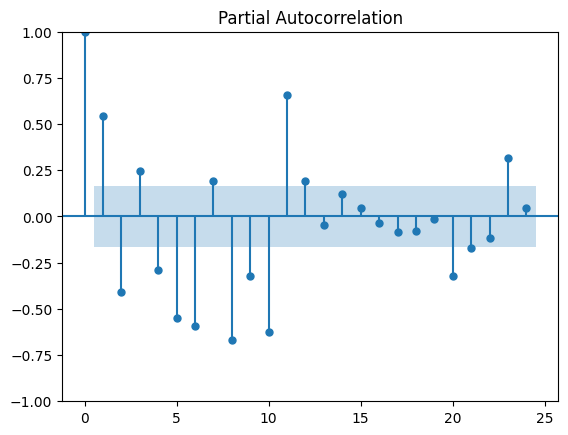

In [58]:
#PACF
# so in graphn the lag is droping(0,1,2,3,.....)in 1st lag the lag is droped in 2nd one so we will take p,q = 1
smt.graphics.plot_pacf(ln_ts_diff2, lags = 24, method='ols')

In [59]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(train, order = (1,2,1),
                                 seasonal_order= (1,0,1,12),
                                             enforce_stationarity=False,
                                             enforce_invertibility=False).fit()

In [60]:
print(model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   No_Tractors_Sold   No. Observations:                  138
Model:             SARIMAX(1, 2, 1)x(1, 0, 1, 12)   Log Likelihood                 222.077
Date:                            Thu, 16 Apr 2026   AIC                           -434.154
Time:                                    00:21:53   BIC                           -420.134
Sample:                                01-01-2003   HQIC                          -428.460
                                     - 06-01-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3573      0.075     -4.755      0.000      -0.505      -0.210
ma.L1         -1.0000     50.936   

In [61]:
f_cast = np.exp(model.forecast(12))

In [62]:
f_cast

2014-07-01    859.159863
2014-08-01    868.513986
2014-09-01    649.176504
2014-10-01    568.061081
2014-11-01    526.141264
2014-12-01    618.062338
2015-01-01    575.363089
2015-02-01    573.897736
2015-03-01    682.027572
2015-04-01    772.760447
2015-05-01    873.336734
2015-06-01    832.894022
Freq: MS, Name: predicted_mean, dtype: float64

In [63]:
sm.tsa.statespace.SARIMAX?

Init signature:
sm.tsa.statespace.SARIMAX(
    endog,
    exog=None,
    order=(1, 0, 0),
    seasonal_order=(0, 0, 0, 0),
    trend=None,
    measurement_error=False,
    time_varying_regression=False,
    mle_regression=True,
    simple_differencing=False,
    enforce_stationarity=True,
    enforce_invertibility=True,
    hamilton_representation=False,
    concentrate_scale=False,
    trend_offset=1,
    use_exact_diffuse=False,
    dates=None,
    freq=None,
    missing='none',
    validate_specification=True,
    **kwargs,
)
Docstring:     
Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors
model

Parameters
----------
endog : array_like
    The observed time-series process :math:`y`
exog : array_like, optional
    Array of exogenous regressors, shaped nobs x k.
order : iterable or iterable of iterables, optional
    The (p,d,q) order of the model for the number of AR parameters,
    differences, and MA parameters. `d` must be an integer
    indicating the 

In [64]:
import sys
import itertools
import warnings

def auto_arima(timeseries, regressors=None, p=range(0, 2), d=range(0, 2), q=range(0, 2),
              P=range(0, 2), D=range(0, 1), Q=range(0, 2)):

    # Generate all different combinations of p, d and q triplets
    pdq = list(itertools.product(p, d, q))

    # Generate all different combinations of seasonal p, q and q triplets
    seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(P, D, Q))]
    
    warnings.filterwarnings("ignore") # specify to ignore warning messages

    best_aic = np.inf
    best_pdq = None
    best_seasonal_pdq = None
    best_results = None
    
    for param in pdq:
        for param_seasonal in seasonal_pdq:

            try:
                temp_model = sm.tsa.statespace.SARIMAX(endog=timeseries,
                                                 exog=regressors,
                                                 order = param,
                                                 seasonal_order = param_seasonal,
                                                 enforce_stationarity=False,
                                                 enforce_invertibility=False)
                temp_results = temp_model.fit()

                print("SARIMAX{}x{}12 - AIC:{}".format(param, param_seasonal, temp_results.aic))
                
                if temp_results.aic < best_aic:
                    best_aic = temp_results.aic
                    best_pdq = param
                    best_seasonal_pdq = param_seasonal
                    best_results = temp_results
                
            except:
                #print("Unexpected error:", sys.exc_info()[0])
                continue
    print("Best SARIMAX{}x{}12 model - AIC:{}".format(best_pdq, best_seasonal_pdq, best_aic))
    print(best_results.summary().tables[0])
    print(best_results.summary().tables[1])
    #return best_results

In [65]:
auto_arima(ln_ts_diff2)

SARIMAX(0, 0, 0)x(0, 0, 0, 12)12 - AIC:-58.9700173826319
SARIMAX(0, 0, 0)x(0, 0, 1, 12)12 - AIC:-159.829425921646
SARIMAX(0, 0, 0)x(1, 0, 0, 12)12 - AIC:-396.3837586934849
SARIMAX(0, 0, 0)x(1, 0, 1, 12)12 - AIC:-423.5753958257128
SARIMAX(0, 0, 1)x(0, 0, 0, 12)12 - AIC:-165.00054015992384
SARIMAX(0, 0, 1)x(0, 0, 1, 12)12 - AIC:-250.53769983208366
SARIMAX(0, 0, 1)x(1, 0, 0, 12)12 - AIC:-429.044192448309
SARIMAX(0, 0, 1)x(1, 0, 1, 12)12 - AIC:-445.39234369384326
SARIMAX(0, 1, 0)x(0, 0, 0, 12)12 - AIC:-71.05380831624755
SARIMAX(0, 1, 0)x(0, 0, 1, 12)12 - AIC:-167.7966803990824
SARIMAX(0, 1, 0)x(1, 0, 0, 12)12 - AIC:-354.5529152879793
SARIMAX(0, 1, 0)x(1, 0, 1, 12)12 - AIC:-374.076216705776
SARIMAX(0, 1, 1)x(0, 0, 0, 12)12 - AIC:-76.18712168997654
SARIMAX(0, 1, 1)x(0, 0, 1, 12)12 - AIC:-172.17368442147915
SARIMAX(0, 1, 1)x(1, 0, 0, 12)12 - AIC:-385.46324054240347
SARIMAX(0, 1, 1)x(1, 0, 1, 12)12 - AIC:-407.71769239050064
SARIMAX(1, 0, 0)x(0, 0, 0, 12)12 - AIC:-107.53058668507511
SARIMAX(1, 

In [66]:
# End of the notebook